📖 개념: [지수 / ETF](../01_knowledge/index-etf.md)

❓ 확인할 것: 미국 주가 데이터는 KRX랑 뭐가 다른지 (지수 vs ETF 포함)

### ① S&P 500 지수(`^GSPC`) 1년치 받기

힌트: `import yfinance as yf` → `yf.download("^GSPC", start="2025-10-01", end="2026-10-01")`

`end`를 `"2026-09-30"`으로 하면 9/30이 들어갈까?

In [52]:
import yfinance as yf
df = yf.download("^GSPC", start="2025-10-01", end="2026-10-01")
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2025-10-01,6711.200195,6718.479980,6656.200195,6664.919922,6037950000
2025-10-02,6715.350098,6731.939941,6693.229980,6731.310059,5416130000
2025-10-03,6715.790039,6750.870117,6705.669922,6722.140137,5713110000
2025-10-06,6740.279785,6749.520020,6717.779785,6733.859863,5604460000
2025-10-07,6714.589844,6754.490234,6699.959961,6746.140137,5546150000
...,...,...,...,...,...
2026-09-24,7704.129883,7719.009766,7662.569824,7666.990234,5316390000
2026-09-25,7743.410156,7752.069824,7693.080078,7709.859863,4499180000


### ② 컬럼이 어떻게 생겼나

힌트: `df.columns`, `df.head()` · `df["Close"]`를 하면 뭐가 나오지? 컬럼 이름이 왜 두 줄?

→ `multi_level_index=False` 옵션을 넣고 다시 받아보기

In [53]:
df.columns

MultiIndex([( 'Close', '^GSPC'),
            (  'High', '^GSPC'),
            (   'Low', '^GSPC'),
            (  'Open', '^GSPC'),
            ('Volume', '^GSPC')],
           names=['Price', 'Ticker'])

In [54]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2025-10-01,6711.200195,6718.479980,6656.200195,6664.919922,6037950000
2025-10-02,6715.350098,6731.939941,6693.229980,6731.310059,5416130000
2025-10-03,6715.790039,6750.870117,6705.669922,6722.140137,5713110000
2025-10-06,6740.279785,6749.520020,6717.779785,6733.859863,5604460000
2025-10-07,6714.589844,6754.490234,6699.959961,6746.140137,5546150000


In [55]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2026-09-24,7704.129883,7719.009766,7662.569824,7666.990234,5316390000
2026-09-25,7743.410156,7752.069824,7693.080078,7709.859863,4499180000
2026-09-28,7683.689941,7724.149902,7666.600098,7721.700195,5129710000
2026-09-29,7670.839844,7699.600098,7653.549805,7699.600098,5023590000
2026-09-30,7651.540039,7722.879883,7651.540039,7688.990234,4276550000


In [56]:
df["Close"]

Ticker,^GSPC
Date,
2025-10-01,6711.200195
2025-10-02,6715.350098
2025-10-03,6715.790039
2025-10-06,6740.279785
2025-10-07,6714.589844
...,...
2026-09-24,7704.129883
2026-09-25,7743.410156
2026-09-28,7683.689941


### ③ `Close` vs `Adj Close`

기본으로 받으면 `Adj Close`가 없음 → `auto_adjust=False`를 넣으면?

힌트: 애플(`AAPL`)과 S&P 500(`^GSPC`) 각각 `(df["Close"] != df["Adj Close"]).sum()` → 왜 한쪽만 다르지?

(pykrx는 `adjusted`로 **둘 중 하나**를 골라 받았음)

In [57]:
df_sp500_adj = yf.download("^GSPC", start="2025-10-01", end="2026-10-01", auto_adjust=False)
df_sp500_adj

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,,
2025-10-01,6711.200195,6711.200195,6718.479980,6656.200195,6664.919922,6037950000
2025-10-02,6715.350098,6715.350098,6731.939941,6693.229980,6731.310059,5416130000
2025-10-03,6715.790039,6715.790039,6750.870117,6705.669922,6722.140137,5713110000
2025-10-06,6740.279785,6740.279785,6749.520020,6717.779785,6733.859863,5604460000
2025-10-07,6714.589844,6714.589844,6754.490234,6699.959961,6746.140137,5546150000
...,...,...,...,...,...,...
2026-09-24,7704.129883,7704.129883,7719.009766,7662.569824,7666.990234,5316390000
2026-09-25,7743.410156,7743.410156,7752.069824,7693.080078,7709.859863,4499180000


In [58]:
df_apple_adj = yf.download("AAPL", start="2025-10-01", end="2026-10-01", auto_adjust=False)
df_apple_adj

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2025-10-01,254.509842,255.449997,258.790009,254.929993,255.039993,48713900
2025-10-02,256.183655,257.130005,258.179993,254.149994,256.579987,42630200
2025-10-03,257.070374,258.019989,259.239990,253.949997,254.669998,49155600
2025-10-06,255.745300,256.690002,259.070007,255.050003,257.989990,44664100
2025-10-07,255.536072,256.480011,257.399994,255.429993,256.809998,31955800
...,...,...,...,...,...,...
2026-09-24,335.920013,335.920013,338.910004,334.299988,336.720001,24733100
2026-09-25,341.070007,341.070007,341.670013,334.529999,336.040009,30002500


In [59]:
(df_sp500_adj["Close"] != df_sp500_adj["Adj Close"]).sum()

Ticker
^GSPC    0
dtype: int64

In [60]:
(df_apple_adj["Close"] != df_apple_adj["Adj Close"]).sum()

Ticker
AAPL    214
dtype: int64

#### 🔍 S&P 500은 0, 애플은 214 — 왜? (지수 vs ETF vs 개별 주식)

| | 정체 | 거래 | 배당 | Close ≠ Adj Close |
|---|---|---|---|---|
| 지수 `^GSPC` | 500개 종목 가격으로 **계산한 점수** | ❌ 못 삼 (보기만 함) | **무시** (가격만으로 계산) | **0일** |
| ETF `SPY` | 지수를 따라가게 500개 종목을 **한 바구니에 담은 상품** | ✅ 주식처럼 사고팜 | 안에 든 종목 배당을 모아서 **분배금**으로 줌 | **242일** |
| 개별 주식 `AAPL` | 회사 주식 | ✅ | 1년에 4번 (11/10, 2/9, 5/11, 8/10 배당락) | **214일** |
| 배당 포함 지수 `^SP500TR` | 배당을 재투자했다고 치고 계산한 지수 | ❌ | 지수 안에 이미 들어감 | 0일 |

- 애플이 S&P 500 안에 있어도 지수는 **배당을 처음부터 무시**함 → 애플이 배당으로 떨어지면 지수도 살짝 떨어진 채로 그냥 둠 → 나중에 고칠 게 없음
- 액면분할은 지수 계산식(나누는 값)에서 그날 미리 흡수 → 지수 값이 안 끊김
- 1년 수익률: `^GSPC` 14.01% vs `^SP500TR` 15.34% → 차이 약 1.3%p = **배당 수익률**. 가격 지수만 보면 실제 수익을 조금 덜 보게 됨

**yfinance `Close`는 이미 액면분할이 반영된 가격** — 애플 2020년 4:1 분할 전날(8/28) 실제로는 약 $499였는데 `Close`는 $124.81. 그래서 `Close`와 `Adj Close` 차이는 **배당 때문에만** 생김 (거래량도 분할 보정됨 — pykrx와 반대)

| | 가격 분할 보정 | 거래량 분할 보정 | 배당 보정 |
|---|---|---|---|
| pykrx (기본) | ✅ | ❌ | ✅ |
| yfinance `Close` | ✅ | ✅ | ❌ |
| yfinance `Adj Close` | ✅ | ✅ | ✅ |


### ④ 1년이 몇 행?

힌트: `df.shape` → KRX 삼성전자 1년치는 241행이었음. 미국은?

In [61]:
df.shape, df_apple_adj.shape, df_sp500_adj.shape

((251, 5), (251, 6), (251, 6))

### ⑤ 지수(`^GSPC`) vs ETF(`SPY`)

같은 기간을 둘 다 받아서 비교

- 가격: `gspc["Close"] / spy["Close"]` → 몇 배?
- 모양: 첫날을 1로 맞춰서 같이 그리기 → `(x["Close"] / x["Close"].iloc[0]).plot()`
- 하루 수익률: `x["Close"].pct_change()` → 개념 노트에 적은 "지수 5% 오를 때 SPY는 4.8~5.1%"가 진짜인지
- 거래량: 지수의 거래량은 무슨 뜻일까?

In [62]:
gspc = yf.download("^GSPC", start="2025-10-01", end="2026-10-01", auto_adjust=False)
spy = yf.download("SPY", start="2025-10-01", end="2026-10-01", auto_adjust=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

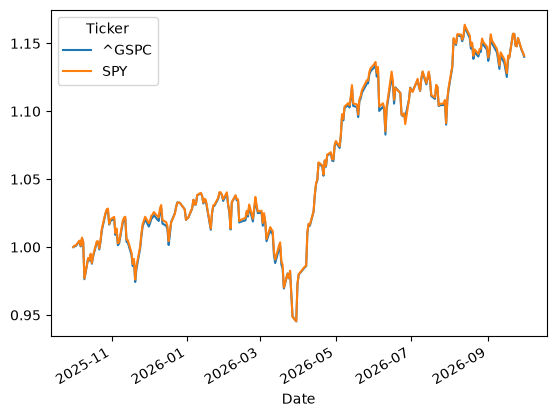

In [63]:
ax = (gspc["Close"] / gspc["Close"].iloc[0]).plot()
(spy["Close"] / spy["Close"].iloc[0]).plot(ax=ax)

In [64]:
gspc["Close"].pct_change()

Ticker,^GSPC
Date,
2025-10-01,NaN
2025-10-02,0.000618
2025-10-03,0.000066
2025-10-06,0.003647
2025-10-07,-0.003811
...,...
2026-09-24,-0.000247
2026-09-25,0.005099
2026-09-28,-0.007712


In [65]:
spy["Close"].pct_change()

Ticker,SPY
Date,
2025-10-01,NaN
2025-10-02,0.001152
2025-10-03,-0.000015
2025-10-06,0.003586
2025-10-07,-0.003707
...,...
2026-09-24,-0.000821
2026-09-25,0.005435
2026-09-28,-0.007441


### ⑥ 다른 라이브러리로 받아도 같은가?

힌트: `import FinanceDataReader as fdr` → `fdr.DataReader("SPY", "2025-10-01", "2026-10-01")` 와 yfinance 결과 비교 · 컬럼 이름·개수가 같은지

In [66]:
import FinanceDataReader as fdr
fdr_spy = fdr.DataReader("SPY", "2025-10-01", "2026-10-01")
fdr_spy

,Open,High,Low,Close,Volume,Adj Close
2025-09-30,662.929993,666.650024,661.609985,666.179993,86288000,659.069458
2025-10-01,663.169983,669.369995,663.059998,668.450012,72545400,661.315369
2025-10-02,670.450012,670.570007,666.780029,669.219971,56896000,662.077026
2025-10-03,669.989990,672.679993,668.159973,669.210022,70494400,662.067200
2025-10-06,671.619995,672.510010,669.460022,671.609985,54623300,664.441589
...,...,...,...,...,...,...
2026-09-24,764.070007,768.950012,763.250000,767.179993,43983700,767.179993
2026-09-25,768.780029,772.280029,766.289978,771.349976,36666700,771.349976
2026-09-28,768.349976,769.539978,763.719971,765.609985,42694500,765.609985
2026-09-29,766.830017,766.979980,762.349976,764.200012,36910500,764.200012


In [67]:
spy

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2025-10-01,661.315308,668.450012,669.369995,663.059998,663.169983,72545400
2025-10-02,662.077026,669.219971,670.570007,666.780029,670.450012,56896000
2025-10-03,662.067200,669.210022,672.679993,668.159973,669.989990,70494400
2025-10-06,664.441528,671.609985,672.510010,669.460022,671.619995,54623300
2025-10-07,661.978210,669.119995,672.989990,667.669983,672.539978,72020100
...,...,...,...,...,...,...
2026-09-24,767.179993,767.179993,768.950012,763.250000,764.070007,43983700
2026-09-25,771.349976,771.349976,772.280029,766.289978,768.780029,36666700


In [68]:
fdr_spy.shape, spy.shape

((252, 6), (251, 6))

In [69]:
fdr_spy.index.difference(spy.index)

DatetimeIndex(['2025-09-30'], dtype='datetime64[ns]', freq=None)

In [70]:
(fdr_spy["Close"] - spy["Close"]).abs().max()

SPY                   NaN
2025-09-30 00:00:00   NaN
2025-10-01 00:00:00   NaN
2025-10-02 00:00:00   NaN
2025-10-03 00:00:00   NaN
                       ..
2026-09-24 00:00:00   NaN
2026-09-25 00:00:00   NaN
2026-09-28 00:00:00   NaN
2026-09-29 00:00:00   NaN
2026-09-30 00:00:00   NaN
Length: 253, dtype: float64

#### 🔍 FinanceDataReader vs yfinance — 결론

비교 방법: ① `shape`로 행 수 → ② `fdr_spy.index.difference(spy.index)`로 다른 날짜 → ③ `(fdr_spy["Close"] - spy_raw["Close"]).abs().max()`로 값 (pandas는 같은 날짜끼리 맞춰서 빼줌)

| | FinanceDataReader | yfinance |
|---|---|---|
| 값 | **같음** — Close·Open·Volume 차이 0, Adj Close 0.0001 (반올림) → 둘 다 Yahoo 데이터로 보임 | |
| 행 수 | 252행 | 251행 |
| 날짜 범위 | 시작일 **하루 전**(2025-09-30)부터 나옴 (❓ 한국·미국 시차 때문으로 보임) | 시작일부터, 종료일은 **미포함** |
| 컬럼 | 1층, `Close`(원래) + `Adj Close`(수정) | 기본 2층, 기본은 `Close`가 이미 수정 가격 |

- ⚠️ 비교할 땐 yfinance도 `auto_adjust=False, multi_level_index=False`로 받아야 같은 조건 (기본 `spy`의 `Close`는 배당 반영된 수정 가격이라 FDR `Close`랑 다름)
- 값은 같고 **날짜 범위·모양만 다름** → 받은 다음 날짜를 직접 잘라서 맞추기: `df.loc["2025-10-01":"2026-09-30"]`


---

## ✍️ 알게 된 것

#### 지수 / ETF / 개별 주식

- 지수 = 여러 종목 가격으로 계산한 점수 (못 삼, 시장 온도계 같은 것)
- ETF = 지수 따라가게 여러 주식을 한 바구니에 담은 상품 (주식처럼 사고팜, "지수를 사는 방법")
- 개별 주식 = 회사 주식 (실제로 사고팜)

#### Close vs Adj Close

- S&P 500 지수는 0일, 애플은 214일, SPY는 242일 다름
- 지수는 배당을 처음부터 무시하고 가격만으로 계산함. 액면분할도 계산식에서 미리 조정함 → 고칠 게 없어서 Close = Adj Close (애플이 지수 안에 있어도)
- ETF랑 개별 주식은 배당이 실제로 있어서 차이 생김
- yfinance `Close`는 이미 액면분할 반영된 가격임 (애플 2020년 분할 전날 실제 $499 → $124.81로 나옴). 그래서 둘 차이는 배당 때문에만 생김. 거래량도 분할 보정됨 (pykrx는 가격만 고쳤음)

#### 배당 보정

- 배당락일에 배당금만큼 가격 떨어지는 건 시장이 하는 거 (데이터가 고친 게 아님)
- 보정 = 배당 이전 과거 가격을 비율로 낮추는 것 (`1 − 배당금 ÷ 전날 종가`를 곱함). 빼는 게 아니라 곱해야 수익률(%)이 유지됨
- 배당 전에 오른 것 같은 진짜 움직임은 그대로 남음. 지우는 건 배당락 가짜 하락뿐
- 그 날짜 **이후에** 있는 배당만 반영됨 (1월·5월 배당이면 2월 가격은 5월 것만). 그래서 오래된 날짜일수록 누적돼서 더 깎임 (KODEX 200 비율이 계단처럼 줄어든 이유)
- 마지막 배당 이후는 Close = Adj Close (애플 9/24 둘 다 335.92)
- 배당금은 회사 배당 발표일에 정해지고, 가격에 반영되는 건 배당락일

#### 1년이 몇 행?

- 미국 1년 = 251행, 한국(삼성전자) = 241행 → 휴장일이 나라마다 다름 (추석·설날은 미국엔 없음)

#### 지수 vs ETF (`^GSPC` vs `SPY`)

- 가격은 약 10배 차이 (SPY가 일부러 지수의 약 1/10 가격이 되게 만든 상품) → 숫자 그대로는 비교 못 함
- 그래서 **첫날 = 1**로 맞춰서 그림 (`x / x.iloc[0]`) → 가격 크기 상관없이 움직임 모양만 비교. 따로 그리면 비교 안 되고 한 그래프에 겹쳐야 함
- 겹쳐 그리면 거의 같음. 1년 누적: 지수 14.01% vs SPY 14.09% (`auto_adjust=False`)
- 기본(`auto_adjust=True`)으로 받으면 SPY는 배당 포함 가격이라 15.32%로 더 높게 나옴 → 지수(배당 무시)랑 비교하면 조건이 다름. **같은 기준으로 맞춰서 비교해야 함** (둘 다 배당 무시: 지수 vs SPY 원래 가격 / 둘 다 배당 포함: `^SP500TR` vs SPY 수정 가격)
- 근데 하루 수익률(`pct_change`)은 매일 조금씩 다름. 차이 크기 평균 0.038%p, 근데 차이 평균은 거의 0 → 플러스·마이너스가 서로 지워져서 누적은 거의 같음
- 매일 다른 이유 = **배당 + 괴리율 + 수수료**
  - 배당: 차이 큰 날 TOP 6 중 4개가 SPY 배당락일 (12/19, 3/20, 6/18, 9/18). SPY는 분기마다 한 번에 모아서 줘서 그날 약 0.3% 빠짐. 지수는 500개 종목이 각자 배당락할 때 이미 조금씩 빠졌음
  - 괴리율: 지수 종가는 종목들 마감가로 계산, SPY 종가는 SPY가 실제로 마지막에 거래된 가격 → 살짝 비싸거나 싸게 끝남. 매일 생기는 작은 차이
  - 수수료: SPY 1년 약 0.09% → 하루로 치면 거의 안 보임
  - 6/26 −0.68%p → 6/29 +0.47%p는 원인 모름 (다음 날 거의 되돌아감)
- **괴리율** = ETF 시장 가격 vs ETF 실제 가치(NAV) → "지금 제값에 팔리나?" / **추적오차** = ETF 수익률 vs 지수 수익률 → "지수를 얼마나 잘 따라가나?" → 둘 다 작을수록 좋음 (괴리율 크면 비싸게 사거나 싸게 팖. 유동성 공급자(LP)가 붙어서 줄여줌)
- 지수 거래량 = 구성 종목 거래량 합 (지수 자체는 거래 안 됨) → SPY 거래량이랑 비교 못 함

#### 지수 vs ETF vs 개별 주식 — 뭘 예측 대상으로?

- 지수: 노이즈(배당·분할·괴리율) 없음, 근데 **못 삼** → 예측 정확도 자체가 목적이면 충분 (논문에서 제일 흔함)
- ETF: 지수랑 거의 같이 움직이면서 **실제로 살 수 있음** → 매매 전략 수익률까지 보여줄 때 (단 수정 가격 써야 배당락 가짜 하락 안 배움)
- 개별 주식: 데이터 많지만 회사 이슈 영향 커서 더 어려움
- 연구 질문 정해지면 따라오는 선택. 논문 읽을 때 **예측 대상 · 수정 가격 여부**도 체크 (재현성)

#### 주의

- 수정 가격은 받은 날짜에 따라 바뀜 (나중에 배당 또 나오면 과거 값도 다시 깎임) → 실험할 땐 받은 날짜 기록하거나 파일로 저장 (재현성)
- 같은 "종가"라도 라이브러리·컬럼마다 뭘 보정했는지 다름 → 모델에 넣을 가격 고를 때 확인, 논문에도 어떤 가격 썼는지 적어야 함
